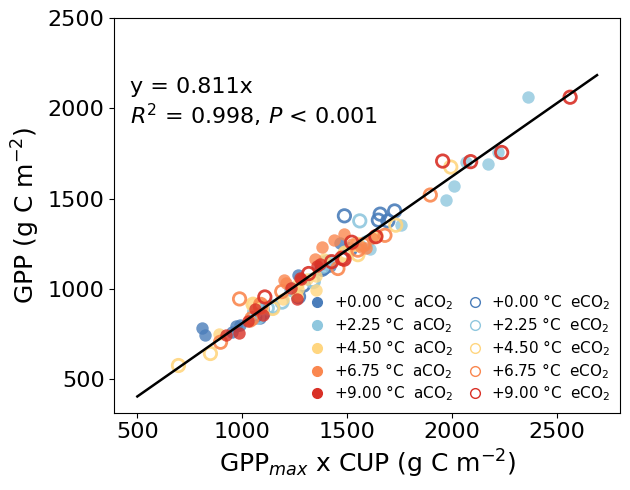

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib.lines import Line2D

# ----------------------------
# Read data
# ----------------------------
file_path = (
    "../../data_results/2_results/2-3_gppmax_cup_6methods/calculated_GPPmax_CUP_ampFracs_10_20_30_25_thresholdScope_ecosystem.xlsx"
)

df_data = pd.read_excel(file_path)

df = df_data[
    ["plot", "year", "co2", "warming",
     "gpp_sum", "gpp_max_whsM", "cup_whsM_25", "alpha_whsM_25"]
].copy()

# ----------------------------
# Derived variable
# ----------------------------
df["gppmax_cup"] = df["gpp_max_whsM"] * df["cup_whsM_25"]

df = df.dropna(subset=["gppmax_cup", "gpp_sum"]).copy()

x = df["gppmax_cup"].to_numpy()
y = df["gpp_sum"].to_numpy()
n = len(x)

# ----------------------------
# Regression: y = kx (no intercept)
# ----------------------------
k = np.sum(x * y) / np.sum(x * x)
y_hat = k * x

ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum(y ** 2)
r2 = 1 - ss_res / ss_tot

sigma2 = ss_res / (n - 1)
se_k = np.sqrt(sigma2 / np.sum(x ** 2))
t_stat = k / se_k
p = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n - 1))

# ----------------------------
# Color mapping for warming
# ----------------------------
warming_levels = sorted(df["warming"].unique())
ls_colors = ["#4a7dba", "#8fc7de", "#ffd680", "#fa874f", "#d93026"]
dict_color = dict(zip(warming_levels, ls_colors))

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6.4, 5))

for w in warming_levels:
    for co2 in [0, 500]:
        df_sub = df[(df["warming"] == w) & (df["co2"] == co2)]
        if df_sub.empty:
            continue

        if co2 == 0:  # aCO2: solid
            ax.scatter(
                df_sub["gppmax_cup"], df_sub["gpp_sum"],
                s=80, color=dict_color[w], alpha=0.8, linewidth=0
            )
        else:  # eCO2: hollow
            ax.scatter(
                df_sub["gppmax_cup"], df_sub["gpp_sum"],
                s=80, facecolors="none", edgecolors=dict_color[w],
                linewidth=2, alpha=0.9
            )

# ----------------------------
# Regression line y = kx
# ----------------------------
xx = np.linspace(500, x.max() * 1.05, 200)
ax.plot(xx, k * xx, linewidth=1.8, color = "k")

# ----------------------------
# Axis labels (with units)
# ----------------------------
ax.set_xlabel("GPP$_{max}$ x CUP (g C m$^{-2}$)", fontsize=18)
ax.set_ylabel("GPP (g C m$^{-2}$)", fontsize=18)
ax.tick_params(labelsize=16)

# ----------------------------
# Statistics annotation
# ----------------------------
p_str = r"$\it{P}$ < 0.001" if p < 0.001 else rf"$\it{{P}}$ = {p:.3f}"
stat_txt = (
    f"y = {k:.3f}x\n"
    f"$R^2$ = {r2:.3f}, {p_str}\n"
    # f"n = {n}"
)
ax.text(
    0.03, 0.85, stat_txt,
    transform=ax.transAxes,
    ha="left", va="top", fontsize=16
)

# ----------------------------
# Legend (10 entries): 2 columns
# Left column = aCO2 (solid), Right column = eCO2 (hollow)
# ----------------------------
handles_a = []
handles_e = []

for w in warming_levels:  # already sorted
    # aCO2 (solid)
    handles_a.append(
        Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=dict_color[w],
               markeredgecolor=dict_color[w],
               markersize=7,
               label=f"+{w:.2f} °C  aCO$_2$")
    )
    # eCO2 (hollow)
    handles_e.append(
        Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor="none",
               markeredgecolor=dict_color[w],
               markersize=7,
               label=f"+{w:.2f} °C  eCO$_2$")
    )

# Important: concatenate as [all aCO2] + [all eCO2]
# so with ncol=2, matplotlib fills columns top-to-bottom.
handles_all = handles_a + handles_e

ax.legend(
    handles=handles_all,
    # title="ambient CO$_2$    elevated CO$_2$",
    loc="lower right",
    ncol=2,
    fontsize=11,
    # title_fontsize=12,
    frameon=False,
    handletextpad=0.1,   # space between marker and text
    columnspacing=0.4,   # space between columns
    labelspacing=0.2,    # vertical spacing between rows
    borderaxespad=0.2    # padding from axes border
)
ax.set_yticks([500, 1000, 1500, 2000,2500])
ax.set_yticklabels([500, 1000, 1500, 2000,2500])
plt.tight_layout()
plt.show()